In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [63]:
df = pd.read_csv("../Data/credit_risk_dataset.csv")

In [64]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [66]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

| Column            | Missing |
| ----------------- | ------- |
| person_emp_length | 895     |
| loan_int_rate     | 3116    |


In [67]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [68]:
df.shape

(32581, 12)

In [69]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

| Column                     | Meaning                  |
| -------------------------- | ------------------------ |
| person_age                 | customer age             |
| person_income              | yearly income            |
| person_home_ownership      | rent/own/mortgage        |
| person_emp_length          | employment years         |
| loan_intent                | reason for loan          |
| loan_grade                 | loan quality             |
| loan_amnt                  | loan amount              |
| loan_int_rate              | interest rate            |
| loan_percent_income        | loan burden              |
| cb_person_default_on_file  | previous default history |
| cb_person_cred_hist_length | credit history length    |


In [70]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [71]:
df["loan_status"].value_counts(normalize=True)

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

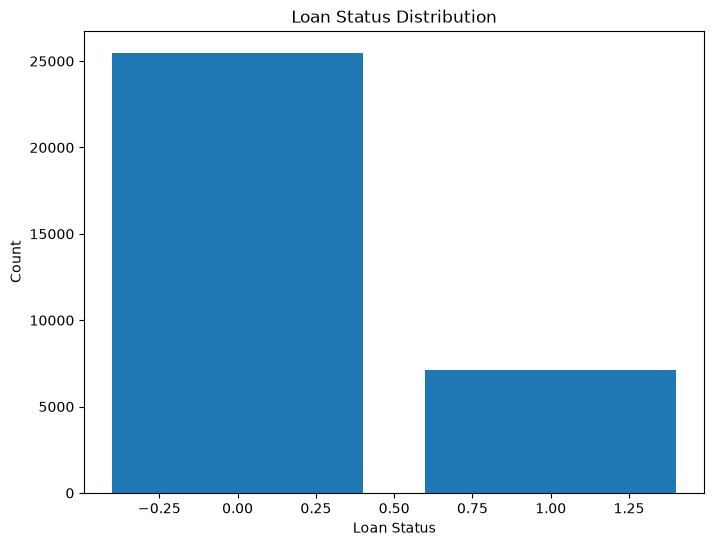

In [72]:
plt.figure(figsize=(8, 6))
plt.bar(df["loan_status"].value_counts().index, df["loan_status"].value_counts())
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


In [73]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

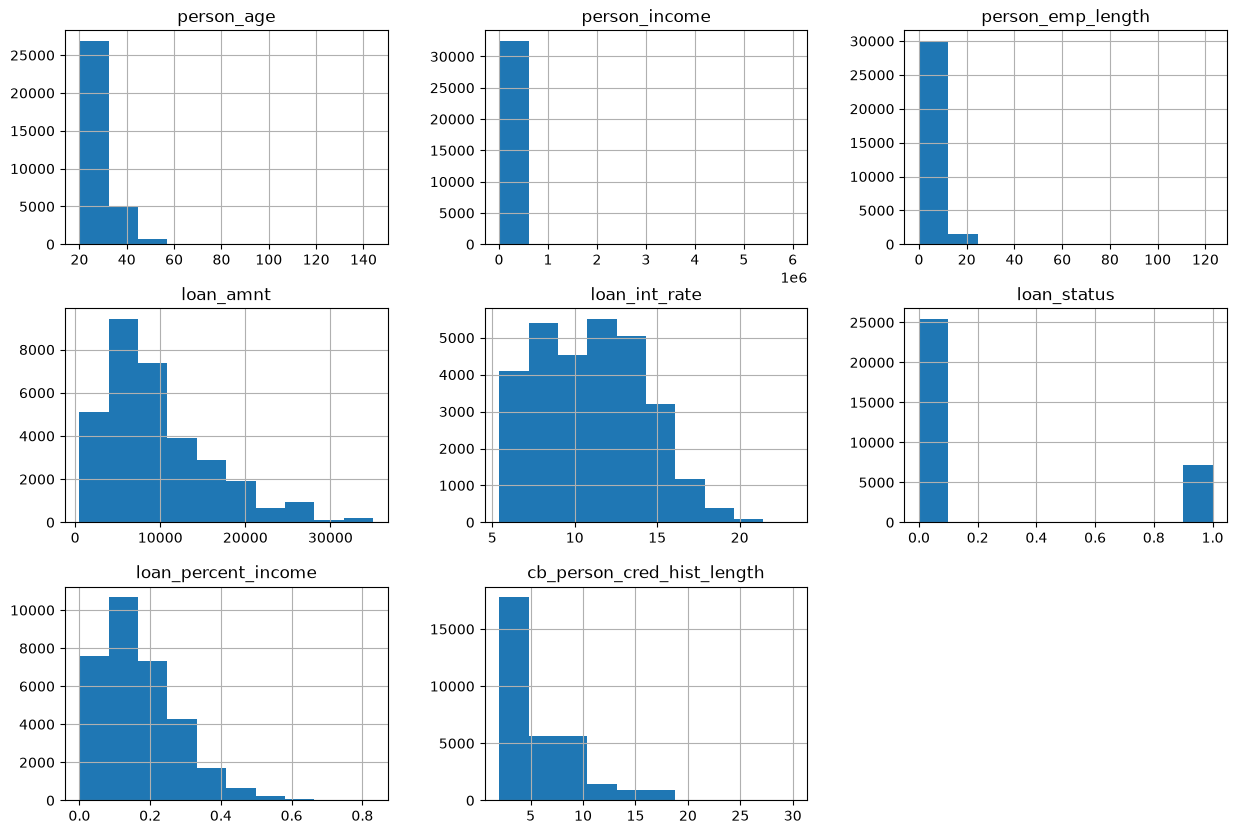

In [74]:
df.hist(figsize=(15,10))
plt.show()

In [75]:
df[["person_age", "person_income", "person_emp_length"]].describe()

,person_age,person_income,person_emp_length
count,32581.000000,3.258100e+04,31686.000000
mean,27.734600,6.607485e+04,4.789686
std,6.348078,6.198312e+04,4.142630
min,20.000000,4.000000e+03,0.000000
25%,23.000000,3.850000e+04,2.000000
50%,26.000000,5.500000e+04,4.000000
75%,30.000000,7.920000e+04,7.000000
max,144.000000,6.000000e+06,123.000000


| Column            | Max Value | Problem             |
| ----------------- | --------- | ------------------- |
| person_age        | 144       | unrealistic         |
| person_income     | 6,000,000 | possible outlier    |
| person_emp_length | 123 years | impossible          |


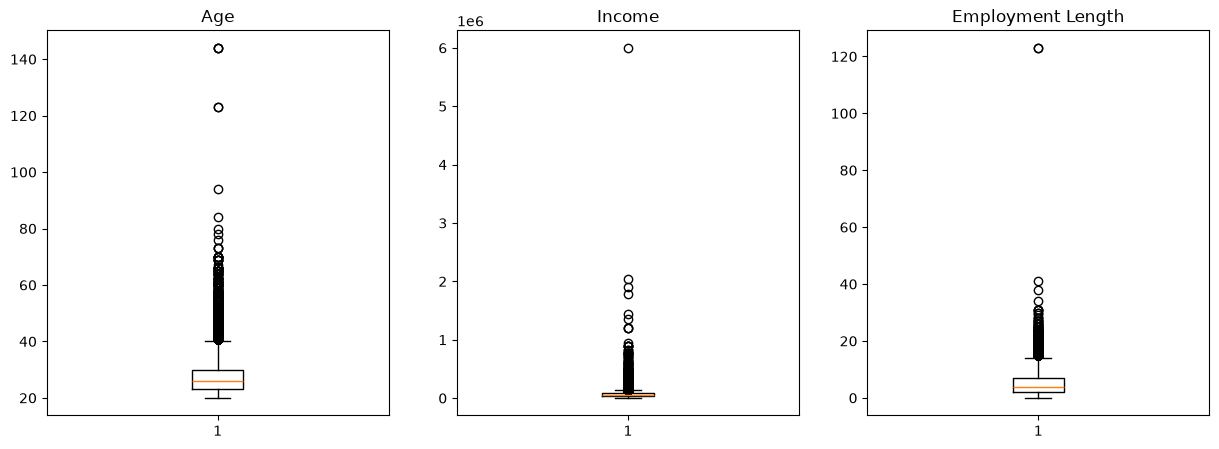

In [76]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.boxplot(df["person_age"].dropna())
plt.title("Age")

plt.subplot(1,3,2)
plt.boxplot(df["person_income"].dropna())
plt.title("Income")

plt.subplot(1,3,3)
plt.boxplot(df["person_emp_length"].dropna())
plt.title("Employment Length")

plt.show()

In [77]:
df = df[df["person_age"] <= 100]

In [78]:
df["person_age"].max()

np.int64(94)

In [79]:
df["person_emp_length"].sort_values(ascending=False).head(10)

210      123.0
0        123.0
32355     41.0
32515     38.0
32428     34.0
32263     31.0
31867     31.0
30914     31.0
31866     31.0
32539     30.0
Name: person_emp_length, dtype: float64

In [80]:
df = df[df["person_emp_length"] <= 60]

In [81]:
df["person_emp_length"].max()

np.float64(41.0)

In [82]:
df["person_income"].sort_values(ascending=False).head(10)

30049    2039784
32546    1900000
32497    1782000
31924    1440000
31922    1362000
29119    1200000
17833    1200000
29120    1200000
17834     948000
32298     900000
Name: person_income, dtype: int64

In [83]:
df["person_income"].max()

np.int64(2039784)

In [84]:
(df.isnull().sum() / len(df)) * 100

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.618359
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [85]:
df["loan_int_rate"].isnull().sum()

np.int64(3047)

In [86]:
df["loan_int_rate"].describe()

count    28632.000000
mean        11.039701
std          3.229409
min          5.420000
25%          7.900000
50%         10.990000
75%         13.480000
max         23.220000
Name: loan_int_rate, dtype: float64

mean = 11.03
median(50%) = 10.99

mean ~ median

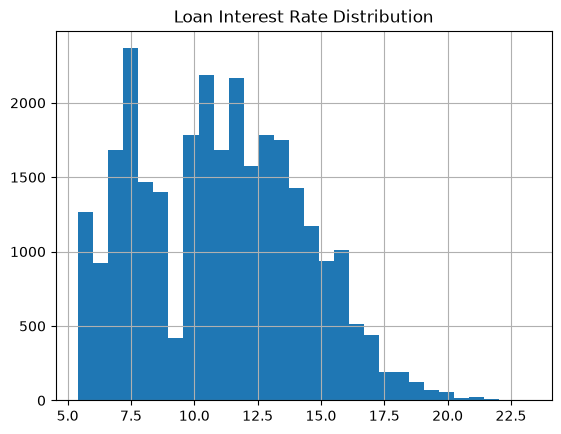

In [87]:
df["loan_int_rate"].hist(bins=30)
plt.title("Loan Interest Rate Distribution")
plt.show()

In [88]:
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].mean())

In [89]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [90]:
cat_col = df.select_dtypes(include=['str']).columns
print(cat_col)

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')


In [91]:
for col in cat_col:
    print("\n")
    print(df[col].value_counts())



person_home_ownership
RENT        16072
MORTGAGE    13090
OWN          2410
OTHER         107
Name: count, dtype: int64


loan_intent
EDUCATION            6288
MEDICAL              5897
VENTURE              5553
PERSONAL             5367
DEBTCONSOLIDATION    5064
HOMEIMPROVEMENT      3510
Name: count, dtype: int64


loan_grade
A    10370
B    10183
C     6319
D     3555
E      952
F      236
G       64
Name: count, dtype: int64


cb_person_default_on_file
N    26051
Y     5628
Name: count, dtype: int64


In [92]:
df = pd.get_dummies(
    df,
    columns=[
        "person_home_ownership",
        "loan_intent",
        "cb_person_default_on_file"
    ],
    drop_first=True
)

In [94]:
from sklearn.preprocessing import LabelEncoder

Encode = LabelEncoder()

df['loan_grade'] = Encode.fit_transform(df['loan_grade'])

In [95]:
df.sample(5)

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
11012,24,71000,4.0,1,14000,10.99,0,0.20,3,False,True,False,False,False,False,True,False,False
6043,22,45900,3.0,0,5750,8.94,0,0.13,3,False,False,True,True,False,False,False,False,False
13328,24,50000,0.0,0,2800,5.79,0,0.06,2,False,False,True,False,False,False,False,False,False
9993,22,50000,0.0,0,9200,6.92,0,0.18,4,False,False,True,True,False,False,False,False,False
3970,23,50000,3.0,2,4000,12.61,0,0.08,2,False,False,True,True,False,False,False,False,True


In [96]:
df.shape

(31679, 18)

In [97]:
df.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'cb_person_default_on_file_Y'],
      dtype='str')